In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/demand.csv")
df["Date"] = pd.to_datetime(df["Date"])

df["Order_Demand"] = (
    df["Order_Demand"]
    .astype(str)
    .str.replace(",","",regex = False)
)

df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors="coerce")

In [4]:
#identifying high demnad product

product_avg = (
    df.groupby("Product_Code")["Order_Demand"]
    .mean()
    .sort_values(ascending = False)
)

high_demand = product_avg.index[0]
print(high_demand)

Product_1245


In [5]:
#Aggregate daily demand for this product

daily_series = (df[df["Product_Code"] == high_demand]
               .groupby("Date",as_index = False)["Order_Demand"]
                .sum()
                .sort_values("Date")
               )
daily_series.head()

,Date,Order_Demand
0,2011-12-28,900000.0
1,2012-01-09,10000.0
2,2012-01-11,75000.0
3,2012-01-16,20000.0
4,2012-01-18,402000.0


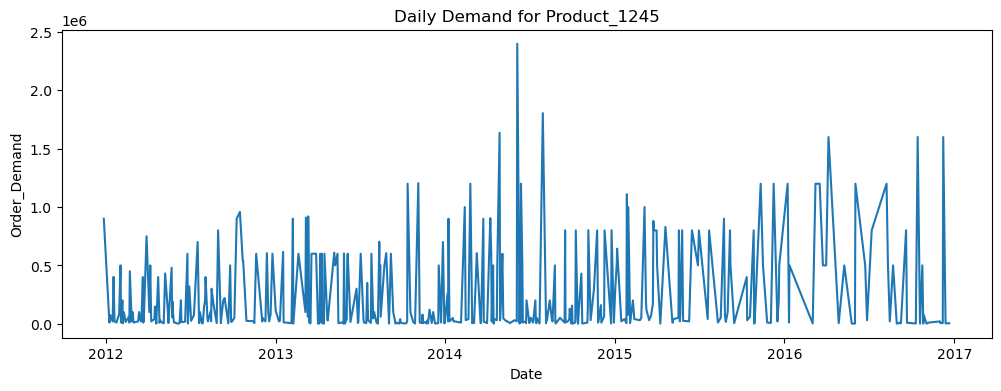

In [6]:
plt.figure(figsize = (12,4))
plt.plot(daily_series["Date"],daily_series["Order_Demand"])
plt.title(f"Daily Demand for {high_demand}")
plt.xlabel("Date")
plt.ylabel("Order_Demand")
plt.show()